In [1]:
import os, sys

EXP_DIR  = os.path.dirname(os.path.abspath('__file__'))
ROOT_DIR = os.path.dirname(os.path.dirname(EXP_DIR))
sys.path.insert(0, EXP_DIR)
sys.path.insert(0, ROOT_DIR)
os.chdir(EXP_DIR)

import numpy as np
import matplotlib.pyplot as plt

from config_dowsampled import make_cfg
from dataset import train_valid_data_loader

cfg = make_cfg()
cfg.data.dataset_root = os.path.join(ROOT_DIR, 'data', 'faces')

_, val_loader, _ = train_valid_data_loader(cfg, distributed=False)
val_dataset = val_loader.dataset

# ── Load synthetic val scan (pair 0 src) ─────────────────────────────────────
VAL_IDX = 0
raw_sample = val_dataset[VAL_IDX]
syn_src_raw = raw_sample['src_points'].astype(np.float32)

# Apply GT transform so src is in ref (face-forward) frame.
# Convention: ref_pt = R @ src_pt + t  →  transform is 4x4 [R|t; 0 1]
transform = raw_sample['transform'].astype(np.float32)  # (4, 4)
R = transform[:3, :3]
t = transform[:3,  3]
syn_src = syn_src_raw @ R.T + t
print(f'Synthetic src: {syn_src.shape}  (transformed to face-forward)')

# ── Load real scan 2189 (same preprocessing as real_scan_diagnostics.ipynb) ──
SCAN_FILE    = '2189.npy'
SCALE_FACTOR = 1 / 1.17
APPLY_FLIP   = True

raw = np.load(os.path.join(EXP_DIR, SCAN_FILE))
real_src = raw[:, :3].astype(np.float32)
real_src /= SCALE_FACTOR
if APPLY_FLIP:
    flip = np.array([[1,0,0],[0,-1,0],[0,0,-1]], dtype=np.float32)
    real_src = real_src @ flip.T
real_src -= real_src.mean(axis=0, keepdims=True)
print(f'Real src:      {real_src.shape}')

Synthetic src: (3561, 3)  (transformed to face-forward)
Real src:      (5660, 3)


In [2]:
def voxel_grid_subsample(points, voxel_size):
    """Keep one point per voxel cell (the one nearest to the cell centroid)."""
    coords = np.floor(points / voxel_size).astype(np.int32)
    # unique voxel keys
    keys = coords[:, 0] * 1_000_003 + coords[:, 1] * 1_009 + coords[:, 2]
    _, first_idx = np.unique(keys, return_index=True)
    return points[first_idx]

voxel=0.030m  syn= 1840 pts   real= 1939 pts
voxel=0.040m  syn= 1439 pts   real= 1265 pts
voxel=0.050m  syn= 1120 pts   real=  867 pts
voxel=0.060m  syn=  874 pts   real=  625 pts


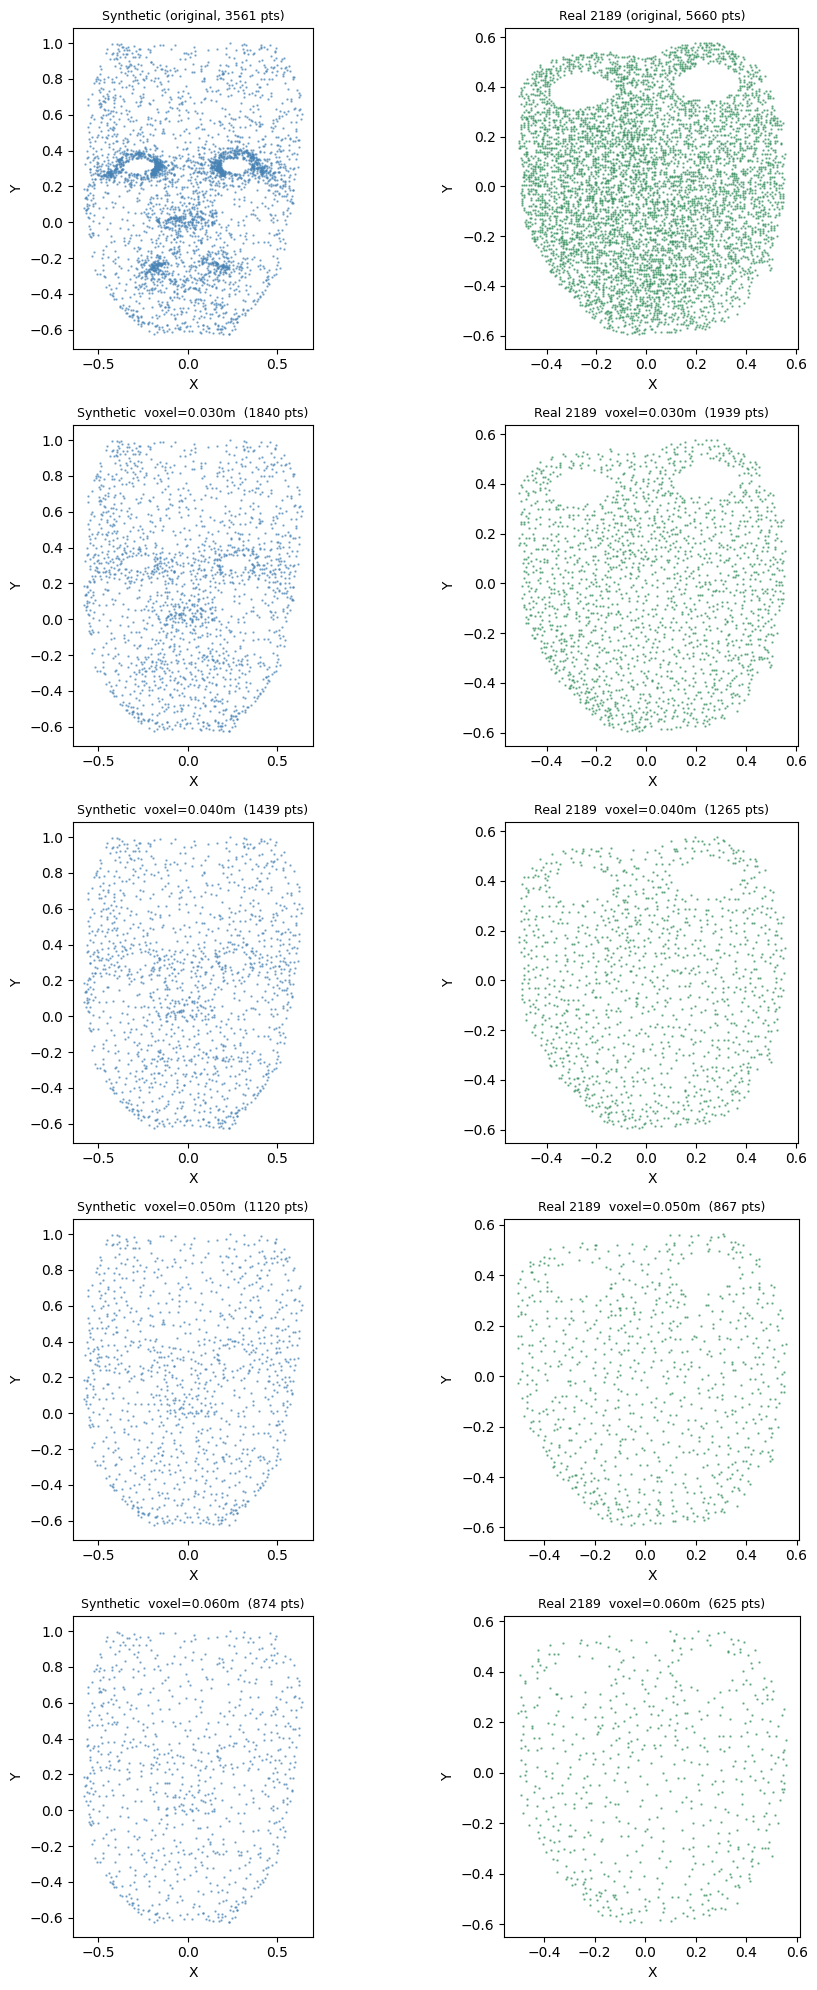

In [3]:
#VOXEL_SIZES = [0.005, 0.010, 0.015, 0.020]
VOXEL_SIZES = [0.03, 0.04, 0.05, 0.06]
n_rows = 1 + len(VOXEL_SIZES)   # original + one row per voxel size

fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
#fig.suptitle('Voxel-grid subsampling: synthetic val vs real scan 2189', fontsize=13)

def plot_pts(ax, pts, title, color):
    ax.scatter(pts[:, 0], pts[:, 1], s=0.5, c=color, alpha=0.6)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('X'); ax.set_ylabel('Y')

# Row 0: originals
plot_pts(axes[0, 0], syn_src,  f'Synthetic (original, {len(syn_src)} pts)', 'steelblue')
plot_pts(axes[0, 1], real_src, f'Real 2189 (original, {len(real_src)} pts)', 'seagreen')

# Rows 1+: voxel-subsampled
for i, vs in enumerate(VOXEL_SIZES):
    syn_v  = voxel_grid_subsample(syn_src,  vs)
    real_v = voxel_grid_subsample(real_src, vs)
    plot_pts(axes[i+1, 0], syn_v,  f'Synthetic  voxel={vs:.3f}m  ({len(syn_v)} pts)',  'steelblue')
    plot_pts(axes[i+1, 1], real_v, f'Real 2189  voxel={vs:.3f}m  ({len(real_v)} pts)', 'seagreen')
    print(f'voxel={vs:.3f}m  syn={len(syn_v):5d} pts   real={len(real_v):5d} pts')

plt.tight_layout()
plt.show()